In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# General info
path_save = "/g/data/up6/ai2733/Gusts_downdrafts/data/"
path_figs = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"

date_cases    = {"CASE1": ("2015-12-15", "2015-12-16"), 
                 "CASE2_new": ("2009-01-19","2009-01-20"), 
                 "CASE3_new": ("2017-02-16","2017-02-17")}
lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                 "CASE3_new": (-31.07,150.84)}
station_cases = {"CASE1": "053115", 
                 "CASE2_new": "072150", 
                 "CASE3_new": "055325"}
name_cases    = {"CASE1": "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}
radar_cases   = {"CASE1": "53",
                 "CASE2_new": "55",
                 "CASE3_new": "69"}
extent_radar = {"CASE1":    [148.29641844830778, 151.39578155169227, -30.839283044092213, -28.14131695590779],
               "CASE2_new": [145.8169722516093, 149.11702774839074, -36.51598304409222, -33.818016955907794],
               "CASE3_new": [148.61764678621688, 151.7657532137831, -32.37258304409221, -29.674616955907783]}

## AWS data

In [3]:
cases = ["CASE1", "CASE2_new", "CASE3_new"]
domains = ["d02", "d03"]
df_aws     = {}
for case in cases:
    df_aws[case] = pd.read_csv(f"{path_save}/AWS/AWS_{case}.csv", index_col = 0, parse_dates = True)
    df_aws[case] = df_aws[case].loc[date_cases[case][1]]

## Figure 1.2: observed gust

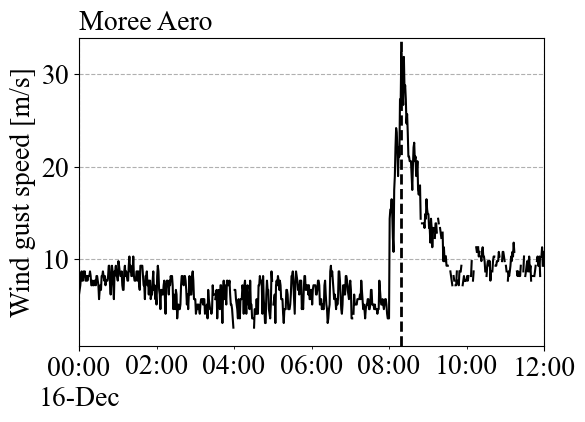

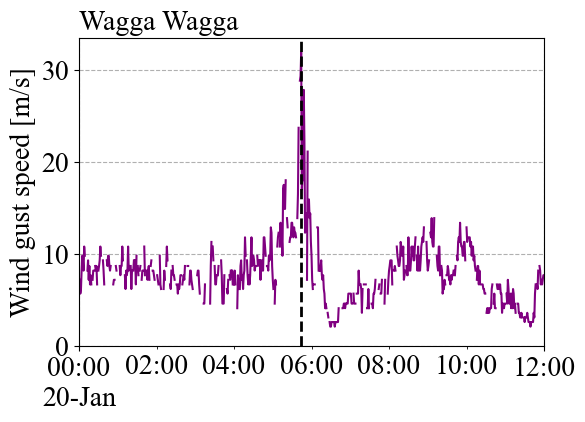

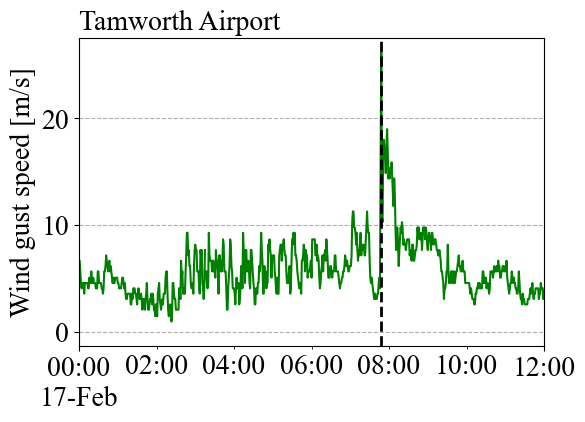

In [4]:
# Plot gust
fs = 20
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

color_cases = {"CASE1":"k", 
              "CASE2_new": "purple", 
              "CASE3_new":"green"}

for case in cases:
    fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4), sharex = False)
    lw_ = 1.5
    ax1 = axes#[0]
    limx = (f"{date_cases[case][1]} 00:00:00", f"{date_cases[case][1]} 12:00:00")

    # Wind gust
    gust = (df_aws[case]["max_ws[km/h]"]/3.6)
    gust.plot(ax = ax1, label = "Wind gust speed", c = color_cases[case], lw = lw_)
    ax1.set_ylabel("Wind gust speed [m/s]", color = "k")
    ax1.set_title(name_cases[case], loc = "left")

    max_time = gust.idxmax()
    max_value = gust.max()
    ax1.axvline(x = max_time, c = 'black', linewidth=2.0, zorder=5, linestyle = "--")

    ax1.set_xlim(limx)
    ax1.grid(ls = "--")
    plt.savefig(f"{path_figs}/Figure1_2_{case}.pdf", dpi = 600, bbox_inches = "tight")
    plt.show()


## Figure 2a,b: observed (other vars)

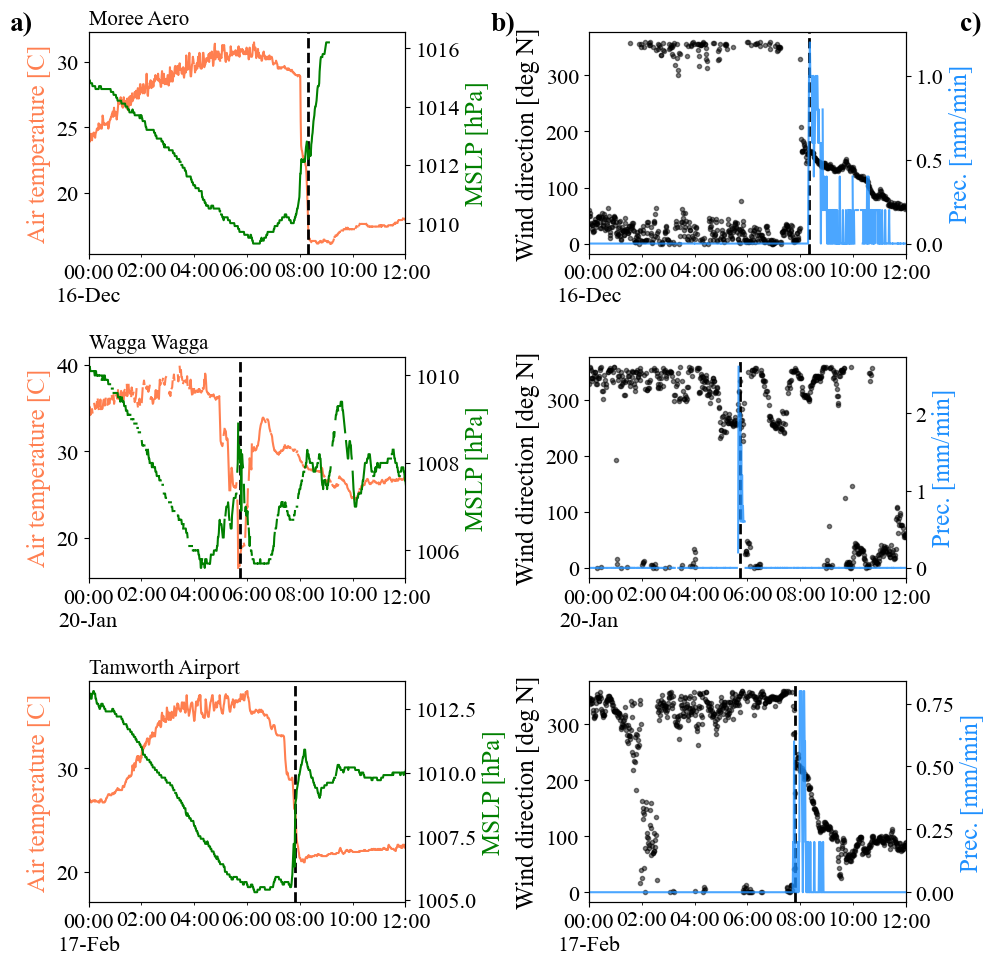

In [5]:
plt.rcParams.update({
    "font.size": 14+4,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": 16+4,       # Title size for subplots
    "axes.labelsize": 14+4,       # Axis label size
    "xtick.labelsize": 12+4,      # X tick label size
    "ytick.labelsize": 12+4,      # Y tick label size
    "legend.fontsize": 12+4,      # Legend font size
    "figure.titlesize": 18+4,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))#, sharex=True)
lw_ = 1.5

for i, case in enumerate(cases):
    limx = (f"{date_cases[case][1]} 00:00:00", f"{date_cases[case][1]} 12:00:00")

    # Left plot:  Temperature + MSLP
    ax1 = axes[i, 0]
    df_aws[case]["ta[C]"].plot(ax=ax1, label="Air temp", c="coral", lw=lw_)
    ax1.set_ylabel("Air temperature [C]", color="coral")
    ax1.set_title(name_cases[case], loc="left", fontsize=15)
    ax1.set_xlim(limx)
    
    # Draw line at max gust time
    gust = (df_aws[case]["max_ws[km/h]"] / 3.6)
    max_time = gust.idxmax()
    max_value = gust.max()
    ax1.axvline(x = max_time, c = 'black', linewidth=2.0, zorder=5, linestyle = "--")

    ax2 = ax1.twinx()
    df_aws[case]["mslp[hPa]"].plot(ax=ax2, label="MSLP", c="green", lw=lw_)
    ax2.set_ylabel("MSLP [hPa]", color="green")
    ax2.set_xlim(limx)

    # Right plot: Wind dir + Precip
    ax3 = axes[i, 1]
    df_aws[case]["wd[deg]"].plot(ax=ax3, label="Wind dir", c="k", lw=lw_, alpha=0.5, 
                                 linestyle="", marker="o", markersize=3)
    ax3.set_ylabel("Wind direction [deg N]", color="k")
    ax3.axvline(x = max_time, c = 'black', linewidth=2.0, zorder=5, linestyle = "--")
    ax3.set_xlim(limx)

    # Create third axis for precipitation
    ax4 = ax3.twinx()
    df_aws[case]["prec[mm]"].plot(ax=ax4, label="Precip", c="dodgerblue", lw=lw_, alpha=0.8)
    ax4.set_ylabel("Prec. [mm/min]", color="dodgerblue")
    ax4.set_xlim(limx)

labels = ['a)', 'b)', 'c)']
pos_y = [0.97,0.66, 0.33]
pos_x = [0.01, 0.49, 0.96]

for i, label in enumerate(labels):
    fig.text(pos_x[i], 0.97, label, fontsize=20, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig(f"{path_figs}Figure2ab.pdf", dpi = 600, bbox_inches = "tight")
plt.show()